<h1>Treinando algoritmo de classificação KNN (K Neartes Neighbors )

In [13]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd

In [4]:
df = pd.read_csv('../archive/IRIS.csv')
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [8]:
df['species_encoded'] = df['species'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})

In [15]:
df_train = df.sample(frac=0.6, random_state=1)
df_test = df.drop(df_train.index)


In [16]:
X_train = df_train.drop(['species', 'species_encoded'], axis=1)
y_train = df_train['species_encoded']
X_test = df_test.drop(['species', 'species_encoded'], axis=1)
y_test = df_test['species_encoded']

In [17]:
KNN = KNeighborsClassifier(n_neighbors=3)
KNN.fit(X_train, y_train)
y_pred = KNN.predict(X_test)

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.95      0.91      0.93        22
           2       0.89      0.94      0.92        18

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



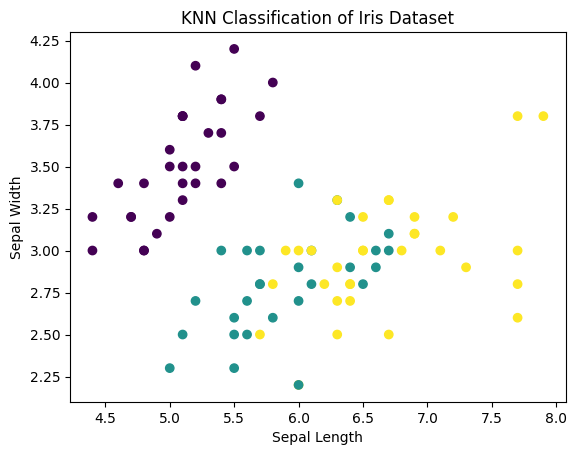

In [20]:
plt.scatter(X_train['sepal_length'], X_train['sepal_width'], c=y_train, cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('KNN Classification of Iris Dataset')
plt.show()

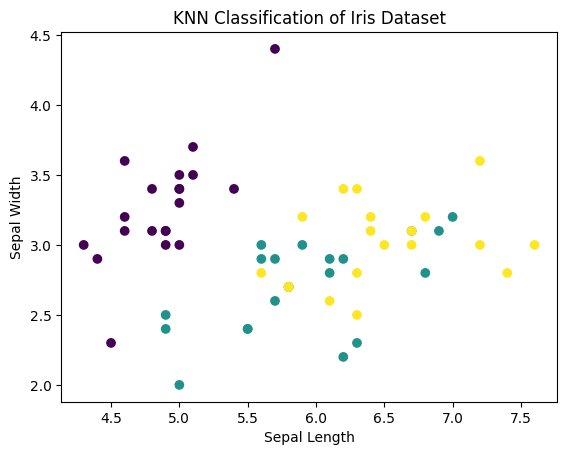

In [21]:
plt.scatter(X_test['sepal_length'], X_test['sepal_width'], c=y_pred, cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('KNN Classification of Iris Dataset')
plt.show()